# Reading and inspecting rasters

What `load_raster` actually gives you, how to interrogate it, and how bands get their names.

- **Data:** the bundled Sentinel-2 sample and Copernicus DEM
- **Network:** only for the first download of the sample

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

## Opening a raster

`load_raster` takes a path - a string, a `pathlib.Path`, or one of the sample handles, which behave like paths.

In [2]:
from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()

scene = load_raster(sd.sentinel2_stacked)
dem = load_raster(sd.copernicus_dem)

scene

<EEORasterDataset 4×1024×1024 uint16 EPSG:32633 [blue, green, red, nir]>

### Opening does not read pixels

This matters for real scenes. `load_raster` opens the file and reads its *header* - CRS, size, dtype, band names - but no pixel data.  
A full Sentinel-2 tile can be opened instantly; the array is read only when an operation needs it.

In [3]:
import time

start = time.perf_counter()
lazy = load_raster(sd.sentinel2_stacked)
opened = time.perf_counter() - start

start = time.perf_counter()
array = lazy.to_array()          # this is the read
read = time.perf_counter() - start

print(f"open : {opened * 1000:6.1f} ms")
print(f"read : {read * 1000:6.1f} ms   -> {array.shape} {array.dtype}")
lazy.close()

open :    7.6 ms
read :  186.7 ms   -> (4, 1024, 1024) uint16


## Describing a dataset

`describe()` prints everything that identifies a raster. It is the fastest way to see whether a file is what you expected.

In [4]:
scene.describe()

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/sentinel2_small.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


Pass `stats=True` to add per-band statistics. This one *does* read pixels, so it costs a pass over the data - `stats="approx"` uses overviews where the file has them and is much cheaper on large scenes.

In [5]:
scene.describe(stats=True)

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/sentinel2_small.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none

  statistics     : exact — full read
  band 1 (blue)  : min 340   max 18496   mean 1552.93   std 463.883   valid 100.0% (0 nodata)
  band 2 (green) : min 358   max 17584   mean 1897.99   std 557.001   valid 100.0% (0 nodata)
  band 3 (red)   : min 1025   max 17024   mean 1780.26   std 733.772   valid 100.0% (0 nodata)
  band 4 (nir)   : min 1245   max 16480   mean 4606.8   std 1000.28   valid 100.0% (0 nodata)


## Individual properties

Each piece of the georeferencing has its own accessor, so you can branch on it in code rather than reading a printout.

In [6]:
print("crs       :", scene.get_crs())
print("shape     :", scene.get_shape(), "(height, width)")
print("width     :", scene.get_width())
print("height    :", scene.get_height())
print("bands     :", scene.get_count())
print("bounds    :", scene.get_bounds())
print("transform :")
print(scene.get_transform())

crs       : EPSG:32633
shape     : (1024, 1024) (height, width)
width     : 1024
height    : 1024
bands     : 4
bounds    : BoundingBox(left=377720.0, bottom=5340230.0, right=387960.0, top=5350470.0)
transform :
| 10.00, 0.00, 377720.00|
| 0.00,-10.00, 5350470.00|
| 0.00, 0.00, 1.00|


The affine transform maps pixel positions to world coordinates. Its `a` and `e` terms are the pixel size - 10 m here, negative in y because rows run north to south.

In [7]:
t = scene.get_transform()
print(f"pixel size : {t.a} x {abs(t.e)} {'m' if scene.get_crs().is_projected else 'deg'}")
print(f"origin     : {t.c}, {t.f}  (top-left corner)")

pixel size : 10.0 x 10.0 m
origin     : 377720.0, 5350470.0  (top-left corner)


`get_metadata()` returns the raw rasterio profile - driver, dtype, nodata and the rest - which is what you would hand to another library.

In [8]:
meta = scene.get_metadata()
for key in ("driver", "dtype", "nodata", "width", "height", "count"):
    print(f"{key:8s}: {meta[key]}")

driver  : GTiff
dtype   : uint16
nodata  : 0.0
width   : 1024
height  : 1024
count   : 4


## Band names

Bands are addressable by name anywhere a 1-based integer is accepted. The sample carries its names in the file itself (GDAL band descriptions), so they are there the moment it is opened.

In [9]:
print("scene:", scene.band_names)
print("dem  :", dem.band_names)

scene: ['blue', 'green', 'red', 'nir']
dem  : ['elevation']


A file without descriptions opens with all-`None` names. Supply them at load time, or set them afterwards - names live in memory and are written to the file only when you call `save_raster`, so a read-only file is never modified.

In [10]:
unnamed = load_raster(sd.sentinel2_blue)
print("as opened      :", unnamed.band_names)

named = load_raster(sd.sentinel2_blue, band_names=["B02"])
print("named at load  :", named.band_names)

named.set_band_name(1, "blue")
print("renamed        :", named.band_names)

unnamed.close()
named.close()

as opened      : ['blue']
named at load  : ['B02']
renamed        : ['blue']


Assigning the whole list at once validates its length against the band count, so a mismatch fails loudly instead of silently mislabelling your data.

In [11]:
from eeo import ValidationError

try:
    scene.band_names = ["blue", "green"]        # scene has four bands
except ValidationError as exc:
    print("ValidationError:", exc)

ValidationError: band_names must have one entry per band; expected 4, got 2


## Getting at the values

`get_band` returns one band as a 2D array; `to_array` returns everything as `(bands, height, width)`. Both accept a band name or a 1-based index.

In [12]:
import numpy as np

nir = scene.get_band("nir")          # same as scene.get_band(4)
print("one band  :", nir.shape, nir.dtype)

cube = scene.to_array()
print("all bands :", cube.shape, cube.dtype)

print(f"\nnir: min {nir.min()}  max {nir.max()}  mean {nir.mean():.0f}")

one band  : (1024, 1024) uint16
all bands : (4, 1024, 1024) uint16

nir: min 1245  max 16480  mean 4607


Note the dtype: Sentinel-2 L2A is stored as `uint16` digital numbers, not reflectance. Divide by 10000 to get surface reflectance - most indices do not care, because a ratio cancels the scale factor, but `evi` does.

In [13]:
reflectance = scene.divide(10000)
print("dtype after divide:", reflectance.get_metadata()["dtype"])
print("nir reflectance range:",
      f"{np.nanmin(reflectance.get_band('nir')):.3f} - {np.nanmax(reflectance.get_band('nir')):.3f}")

dtype after divide: float32
nir reflectance range: 0.124 - 1.648


## Nodata

A raster *declares* a nodata value in its header. Easy-EO excludes those pixels from statistics and propagates them through every operation: a pixel that is nodata in any input is nodata in the output.

Declaring a value is not the same as containing it - this subset was cut from the interior of a Sentinel-2 tile, so it declares `0` but has no nodata pixels at all. You see the machinery in action as soon as you clip (see [02_clip_and_mosaic] 02_clip_and_mosaic.ipynb)), which fills the outside of the polygon with exactly this value.

In [14]:
nodata_value = scene.get_metadata()["nodata"]
raw = scene.get_band("nir")

print("declared nodata     :", nodata_value)
print("pixels holding it   :", int((raw == nodata_value).sum()), "of", raw.size)

declared nodata     : 0.0
pixels holding it   : 0 of 1048576


## Wrapping an array you already have

`load_array` turns a NumPy array into a dataset, so anything you compute elsewhere can re-enter an Easy-EO chain. Give it a CRS and a transform to make it georeferenced - here, the same grid as the scene, offset to its top-left corner.

In [15]:
from affine import Affine

from eeo import load_array

values = np.linspace(0, 1, 64 * 64, dtype="float32").reshape(64, 64)

synthetic = load_array(
    values,
    crs=scene.get_crs(),
    transform=Affine(10.0, 0.0, 377720.0, 0.0, -10.0, 5350470.0),
    nodata=np.nan,
    band_names=["gradient"],
)
synthetic.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 1
  band names  : 1: gradient
  size        : 64 × 64  (height × width)
  dtype       : float32
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5349830, 378360, 5350470  (minx, miny, maxx, maxy)
  nodata      : nan
  timestamp   : none
  attrs       : none


## Plotting a quick look

Plot functions read at *display* resolution rather than pulling the full array
into memory, so previewing a large scene is cheap.

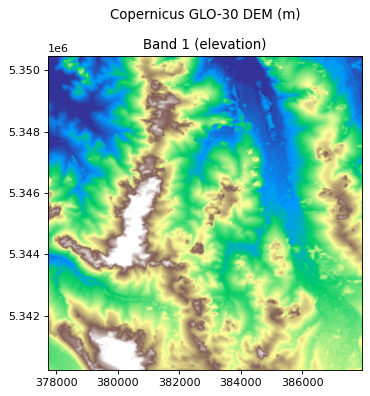

In [16]:
dem.plot_raster(cmap="terrain", title="Copernicus GLO-30 DEM (m)")

## Closing

Datasets hold an open file handle. Close them when you are done - terminal operations such as the plot functions close their own intermediate results automatically.

In [17]:
for ds in (scene, dem, reflectance, synthetic):
    ds.close()
print("closed")

closed


## Next

- **[02_clip_and_mosaic](02_clip_and_mosaic.ipynb)** - cut a scene to an area of interest and merge tiles
- **[07_visualization](07_visualization.ipynb)** - the full plotting toolkit